In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

x0, y0, h, x_end = 0, 0.5, 0.4, 3.0
err_steps = [0.1, 0.05, 0.025, 0.0125]


In [2]:
def exact_solution(x):
    return (x+1)**2 - 0.5*np.exp(x)

def f(x, y):
    return y - x**2 + 1

def runge_kutta_4(f, x0, y0, x_end, h):
    x = np.arange(x0, x_end + h, h)
    y = np.zeros(len(x))
    y[0] = y0
    for i in range(len(x)-1):
        k1 = f(x[i], y[i])
        k2 = f(x[i] + h/2, y[i] + h/2 * k1)
        k3 = f(x[i] + h/2, y[i] + h/2 * k2)
        k4 = f(x[i] + h, y[i] + h * k3)
        y[i+1] = y[i] + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    return x, y


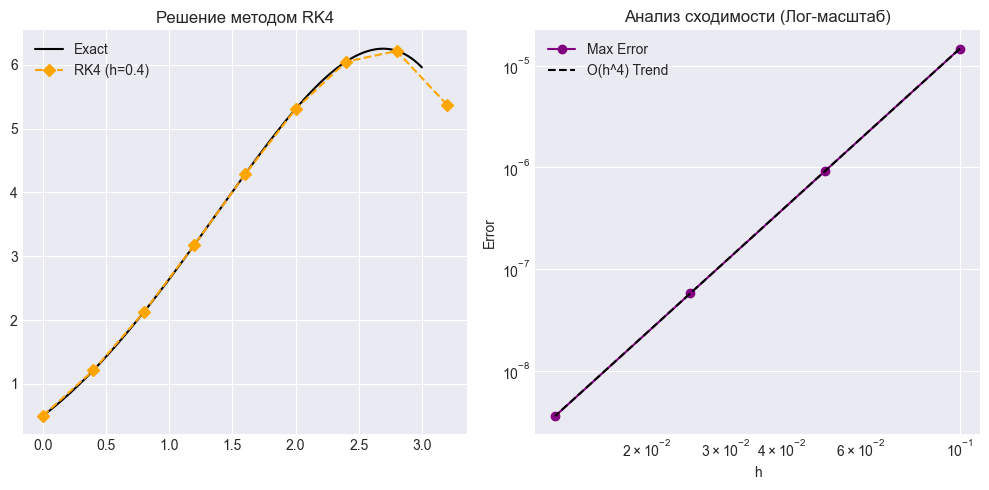

In [3]:
x_exact = np.linspace(x0, x_end, 500)
x_rk, y_rk = runge_kutta_4(f, x0, y0, x_end, h)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.plot(x_exact, exact_solution(x_exact), 'k-', label='Exact')
plt.plot(x_rk, y_rk, 'D--', color='orange', label=f'RK4 (h={h})')
plt.title('Решение методом RK4')
plt.legend()

errors = []
for step in err_steps:
    x_r, y_r = runge_kutta_4(f, x0, y0, x_end, step)
    y_true = exact_solution(x_r)
    errors.append(np.max(np.abs(y_r - y_true)))

plt.subplot(1, 2, 2)
plt.loglog(err_steps, errors, 'o-', color='purple', label='Max Error')
plt.loglog(err_steps, np.array(err_steps)**4 * (errors[0]/(err_steps[0]**4)), 'k--', label='O(h^4) Trend')
plt.title('Анализ сходимости (Лог-масштаб)')
plt.xlabel('h')
plt.ylabel('Error')
plt.legend()
plt.tight_layout()
plt.show()
